# Фаза 1: Эксперименты по улучшению RAG

Эксперименты по улучшению **ретривера** и **генератора**: подбор top-k, размера чанка, эмбеддера, фильтра по метаданным, two-stage извлечения с реранкером, модели LLM и температуры генерации ответов.

7 этапов:

1. **Этап 1 - top-k × размер чанка:** сетка комбинаций `(top_k, chunk_size)`. Для каждого размера чанка (128, 256, 512) - свой датасет на HF и своя коллекция Qdrant.
2. **Этап 2 - модель-эмбеддер:** при выбранных top_k и chunk_size перебираются эмбеддеры. Для каждого - своя коллекция и переиндексация; датасет тот же с HF (под выбранный chunk_size).
3. **Этап 3 - фильтр по метаданным:** при выбранных top_k, chunk_size и эмбеддере - использование метаданных (название игры) при поиске: `retrieval.use_metadata_filter=true` vs `false`, фильтр по `game_titles` в Qdrant.
4. **Этап 4 - two-stage retrieval:** при тех же настройках - two-stage retrieval с реранкером (first_stage_k -> реранкер -> second_stage_k): `retrieval.two_stage=true` vs `false`.
5. **Этап 5 - подбор first_stage_k и second_stage_k:** при включённом two-stage - сетка по `first_stage_k` (20, 30, 40, 50) и `second_stage_k` (3, 5, 7, 10), выбор лучшей пары по метрикам ретривера.
6. **Этап 6 - подбор модели генератора (LLM):** при фиксированных лучших настройках ретривера перебор модели генерации; для каждой: ChrF++, ROUGE, semantic similarity, LLM-judge (faithfulness, relevance, correctness).
7. **Этап 7 - подбор температуры генерации:** при выбранной модели генератора перебор температуры (0.0–0.3). Для каждой температуры - 3 прогона для проверки устойчивости. Агрегация mean/std по метрикам пайплайна.

**Бейзлайн:** эмбеддер `intfloat/multilingual-e5-base`, коллекция под выбранный chunk size, генератор `qwen2.5:1.5b`.

**Датасеты:** загружаются с Hugging Face Hub (конфиг `data.eval_dataset_hf_repo`). Файлы: `boardgame_rules_qa_dataset_ru_chunk128.jsonl`, `boardgame_rules_qa_dataset_ru_chunk256.jsonl`, `boardgame_rules_qa_dataset_ru_chunk512.jsonl`. Коллекции Qdrant подготавливаются заранее (локально).

## Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from omegaconf import OmegaConf
from src.config import BASE_DIR, get_cfg, paths_from_cfg
from src.eval import run_full_evaluation, run_retriever_evaluation
from src.indexer import index_documents

RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(exist_ok=True)
paths = paths_from_cfg(get_cfg())
EVAL_DATASETS_DIR = paths["eval_datasets_dir"]
EVAL_DATASET_HF_REPO = OmegaConf.select(get_cfg(), "data.eval_dataset_hf_repo", default=None) or ""
print("Results dir:", RESULTS_DIR.relative_to(BASE_DIR))
print("Eval datasets: HF repo =", EVAL_DATASET_HF_REPO or "(not set)")

Results dir: research/rag_experiments/results
Eval datasets: HF repo = LHLHLHE/boardgame_rules_qa_dataset_ru


## Подготовка: датасеты и коллекции для chunk-size 128, 256, 512

Для каждого размера чанка нужны: датасет `boardgame_rules_qa_dataset_ru_chunk{S}.jsonl` и коллекция Qdrant `boardgame_rules_chunk{S}`. Запустите один раз (из корня `research/rag_experiments`):

```bash
python scripts/prepare_chunk_datasets_and_collections.py
```

Или только датасеты: `--skip-index`; только индексация: `--skip-datasets`.

In [2]:
# Имена файлов датасетов на HF для этапа 1 (chunk 128, 256, 512)
for s in (128, 256, 512):
    fname = f"boardgame_rules_qa_dataset_ru_chunk{s}.jsonl"
    print(f"  {fname}: repo={EVAL_DATASET_HF_REPO or 'NOT SET'}")

  boardgame_rules_qa_dataset_ru_chunk128.jsonl: repo=LHLHLHE/boardgame_rules_qa_dataset_ru
  boardgame_rules_qa_dataset_ru_chunk256.jsonl: repo=LHLHLHE/boardgame_rules_qa_dataset_ru
  boardgame_rules_qa_dataset_ru_chunk512.jsonl: repo=LHLHLHE/boardgame_rules_qa_dataset_ru


## Этап 1 - сетка top-k × chunk size

In [3]:
TOPK_VALUES = [3, 5, 7, 10]
CHUNK_SIZES = [128, 256, 512]
TOPK_CHUNK_GRID = []
for top_k in TOPK_VALUES:
    for chunk_size in CHUNK_SIZES:
        TOPK_CHUNK_GRID.append({
            "id": f"topk{top_k}_chunk{chunk_size}",
            "overrides": [
                f"retrieval.top_k={top_k}",
                f"qdrant.collection_name=boardgame_rules_chunk{chunk_size}",
            ],
            "dataset_hf_filename": f"boardgame_rules_qa_dataset_ru_chunk{chunk_size}.jsonl",
            "top_k": top_k,
            "chunk_size": chunk_size,
        })
print(f"Phase 1 grid: {len(TOPK_CHUNK_GRID)} experiments")

Phase 1 grid: 12 experiments


In [4]:
RUN_PHASE1 = True
LIMIT = None
SKIP_IF_EXISTS = True

phase1_results = []
for item in TOPK_CHUNK_GRID:
    exp_id = item["id"]
    overrides = item["overrides"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if RUN_PHASE1:
        if SKIP_IF_EXISTS and out_path.exists():
            print(f"Skip (exists): {exp_id}")
            with open(out_path, encoding="utf-8") as f:
                phase1_results.append(json.load(f))
            continue
        if not EVAL_DATASET_HF_REPO:
            print("Skip: EVAL_DATASET_HF_REPO not set")
            break
        print(f"Running: {exp_id} top_k={item['top_k']} chunk_size={item['chunk_size']}")
        cfg = get_cfg(overrides)
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["top_k"] = item["top_k"]
        result["chunk_size"] = item["chunk_size"]
        result["embedding_model"] = result["models"]["embedding"]
        to_save = {
            "experiment_id": exp_id,
            "top_k": result["top_k"],
            "chunk_size": result["chunk_size"],
            "embedding_model": result["embedding_model"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase1_results.append(result)
    else:
        if out_path.exists():
            with open(out_path, encoding="utf-8") as f:
                phase1_results.append(json.load(f))
        else:
            print(f"Missing: {exp_id}")

print(f"Phase 1: {len(phase1_results)} results.")

Skip (exists): topk3_chunk128
Skip (exists): topk3_chunk256
Skip (exists): topk3_chunk512
Skip (exists): topk5_chunk128
Skip (exists): topk5_chunk256
Skip (exists): topk5_chunk512
Skip (exists): topk7_chunk128
Skip (exists): topk7_chunk256
Skip (exists): topk7_chunk512
Skip (exists): topk10_chunk128
Skip (exists): topk10_chunk256
Skip (exists): topk10_chunk512
Phase 1: 12 results.


In [5]:
rows = []
for r in phase1_results:
    row = {
        "experiment_id": r.get("experiment_id", ""),
        "top_k": r.get("top_k"),
        "chunk_size": r.get("chunk_size"),
        "embedding_model": r.get("embedding_model", r.get("models", {}).get("embedding", "")),
    }
    for k, v in r.get("retriever", {}).items():
        if k != "precision_at_k":
            row[k] = v
    rows.append(row)

phase1_df = pd.DataFrame(rows)

In [6]:
phase1_pivot = phase1_df.set_index(["chunk_size", "top_k"])
phase1_pivot

,,experiment_id,embedding_model,recall_at_k,map_at_k,ndcg_at_k,hit_rate
chunk_size,top_k,,,,,,
128,3,topk3_chunk128,intfloat/multilingual-e5-base,0.687500,0.589306,0.638267,0.815
256,3,topk3_chunk256,intfloat/multilingual-e5-base,0.663333,0.572778,0.617318,0.765
512,3,topk3_chunk512,intfloat/multilingual-e5-base,0.595000,0.504722,0.541591,0.665
128,5,topk5_chunk128,intfloat/multilingual-e5-base,0.746667,0.607597,0.667236,0.875
256,5,topk5_chunk256,intfloat/multilingual-e5-base,0.749167,0.600069,0.656322,0.825
512,5,topk5_chunk512,intfloat/multilingual-e5-base,0.693333,0.533222,0.585582,0.750
128,7,topk7_chunk128,intfloat/multilingual-e5-base,0.786667,0.616149,0.682950,0.905
256,7,topk7_chunk256,intfloat/multilingual-e5-base,0.797500,0.609673,0.675405,0.875
512,7,topk7_chunk512,intfloat/multilingual-e5-base,0.785833,0.550603,0.619984,0.835


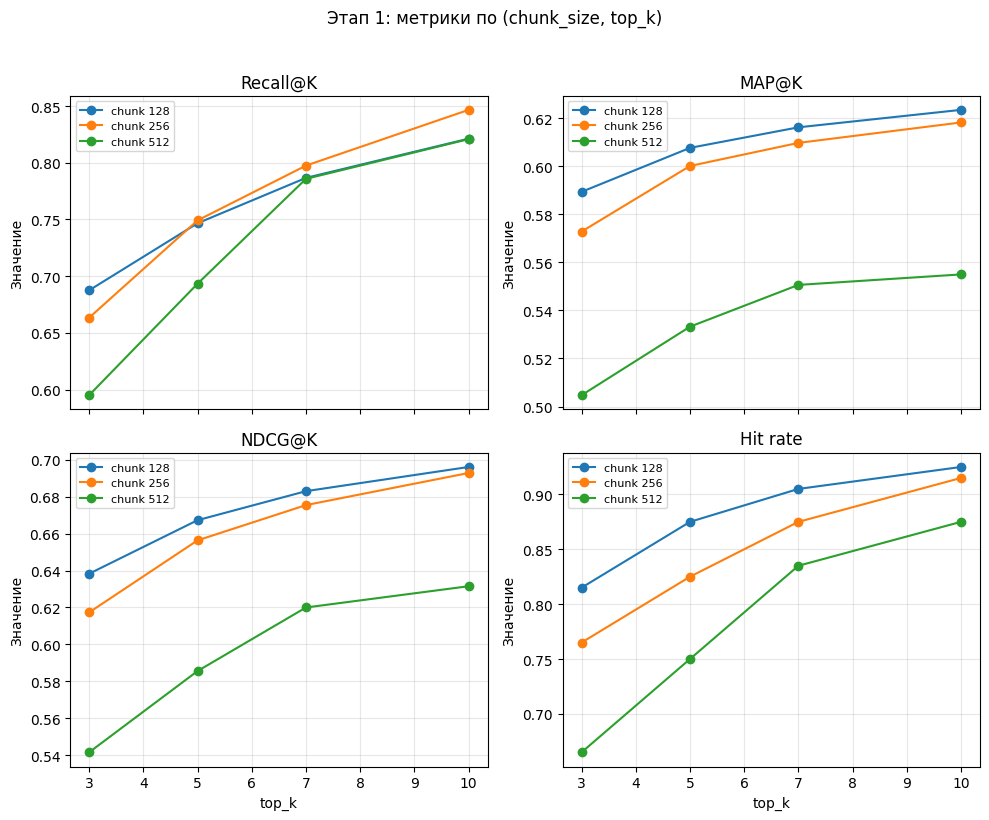

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes = axes.flatten()
metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
metric_titles = {
    "recall_at_k": "Recall@K",
    "map_at_k": "MAP@K",
    "ndcg_at_k": "NDCG@K",
    "hit_rate": "Hit rate",
}
chunk_sizes = sorted(phase1_df["chunk_size"].unique())
for idx, m in enumerate(metrics):
    ax = axes[idx]
    for chunk_size in chunk_sizes:
        sub = phase1_df[phase1_df["chunk_size"] == chunk_size].sort_values("top_k")
        if m not in sub.columns:
            continue
        x = sub["top_k"].astype(int)
        ax.plot(x, sub[m], marker="o", label=f"chunk {chunk_size}")
    ax.set_title(metric_titles.get(m, m))
    ax.set_ylabel("Значение")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[2].set_xlabel("top_k")
axes[3].set_xlabel("top_k")
plt.suptitle("Этап 1: метрики по (chunk_size, top_k)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

- **Главный критерий выбора**: качество ранжирования (**NDCG@K** и **MAP@K**), т.к. в генерацию реально попадают только top-K чанков; важно, чтобы релевантные были как можно выше в выдаче.
- **Наблюдение по результатам**: `chunk_size=128` даёт лучшую картину по **MAP@K**, **NDCG@K** и **Hit rate**.
- **Recall@K** местами выше у `chunk_size=256`, но при текущем датасете (максимум 3 gold-чанка на пример) recall быстро выходит на плато при росте K, поэтому при сравнении эту метрику используем как дополнительную проверку, а не как основную цель.

**Лучший набор параметров для следующих этапов:**

- **`BEST_CHUNK_SIZE = 128`**
- **`BEST_TOP_K = 10`**

## Этап 2 - эмбеддеры

In [8]:
# Выбор лучшей пары из этапа 1
BEST_TOP_K = 10
BEST_CHUNK_SIZE = 128
CHUNK_OVERLAP = {128: 20, 256: 40, 512: 80}.get(BEST_CHUNK_SIZE, 80)
PHASE2_DATASET_HF_FILENAME = f"boardgame_rules_qa_dataset_ru_chunk{BEST_CHUNK_SIZE}.jsonl"

# Сетка эмбеддеров
EMBEDDER_GRID = [
    {
        "id": f"embed_e5_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}",
        ],
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
    {
        "id": f"embed_rosberta_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"chunking.chunk_size={BEST_CHUNK_SIZE}",
            f"chunking.chunk_overlap={CHUNK_OVERLAP}",
            "embedding.model=ai-forever/ru-en-RoSBERTa",
            "embedding.dim=1024",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}_rosberta",
        ],
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
    {
        "id": f"embed_mpnet_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"chunking.chunk_size={BEST_CHUNK_SIZE}",
            f"chunking.chunk_overlap={CHUNK_OVERLAP}",
            "embedding.model=sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
            "embedding.dim=768",
            "embedding.text_instruction=\"\"",
            "embedding.query_instruction=\"\"",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}_mpnet",
        ],
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
    {
        "id": f"embed_gte_chunk{BEST_CHUNK_SIZE}",
        "overrides": [
            f"retrieval.top_k={BEST_TOP_K}",
            f"chunking.chunk_size={BEST_CHUNK_SIZE}",
            f"chunking.chunk_overlap={CHUNK_OVERLAP}",
            "embedding.model=Alibaba-NLP/gte-multilingual-base",
            "embedding.dim=768",
            "embedding.text_instruction=\"\"",
            "embedding.query_instruction=\"\"",
            f"qdrant.collection_name=boardgame_rules_chunk{BEST_CHUNK_SIZE}_gte",
        ],
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "top_k": BEST_TOP_K,
        "chunk_size": BEST_CHUNK_SIZE,
        "run_index_first": False,
    },
]
print(f"Phase 2: {len(EMBEDDER_GRID)} embedder experiments (best top_k={BEST_TOP_K}, chunk_size={BEST_CHUNK_SIZE})")

Phase 2: 4 embedder experiments (best top_k=10, chunk_size=128)


In [9]:
RUN_PHASE2 = True
phase2_results = []
for item in EMBEDDER_GRID:
    exp_id = item["id"]
    overrides = item["overrides"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if RUN_PHASE2:
        if SKIP_IF_EXISTS and out_path.exists():
            print(f"Skip (exists): {exp_id}")
            with open(out_path, encoding="utf-8") as f:
                phase2_results.append(json.load(f))
            continue
        if not EVAL_DATASET_HF_REPO:
            print("Skip: EVAL_DATASET_HF_REPO not set")
            break
        print(f"Running: {exp_id}")
        cfg = get_cfg(overrides)
        if item.get("run_index_first"):
            index_documents(cfg, recreate_collection=True, batch_size=200)
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["top_k"] = item["top_k"]
        result["chunk_size"] = item["chunk_size"]
        result["embedding_model"] = result["models"]["embedding"]
        to_save = {
            "experiment_id": exp_id,
            "top_k": result["top_k"],
            "chunk_size": result["chunk_size"],
            "embedding_model": result["embedding_model"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase2_results.append(result)
    else:
        if out_path.exists():
            with open(out_path, encoding="utf-8") as f:
                phase2_results.append(json.load(f))
        else:
            print(f"Missing: {exp_id}")
print(f"Phase 2: {len(phase2_results)} results.")

Skip (exists): embed_e5_chunk128
Skip (exists): embed_rosberta_chunk128
Skip (exists): embed_mpnet_chunk128
Skip (exists): embed_gte_chunk128
Phase 2: 4 results.


In [10]:
rows = []
for r in phase2_results:
    row = {
        "experiment_id": r.get("experiment_id", ""),
        "top_k": r.get("top_k"),
        "chunk_size": r.get("chunk_size"),
        "embedding_model": r.get("embedding_model", r.get("models", {}).get("embedding", "")),
    }
    for k, v in r.get("retriever", {}).items():
        if k != "precision_at_k":
            row[k] = v
    rows.append(row)
phase2_df = pd.DataFrame(rows)
display_cols = ["experiment_id", "embedding_model", "top_k", "chunk_size"] + ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
display_cols = [c for c in display_cols if c in phase2_df.columns]

In [11]:
phase2_pivot = phase2_df.set_index(["embedding_model"])
phase2_pivot

,experiment_id,top_k,chunk_size,recall_at_k,map_at_k,ndcg_at_k,hit_rate
embedding_model,,,,,,,
intfloat/multilingual-e5-base,embed_e5_chunk128,10,128,0.821250,0.623409,0.696042,0.925
ai-forever/ru-en-RoSBERTa,embed_rosberta_chunk128,10,128,0.747500,0.522077,0.595737,0.845
sentence-transformers/paraphrase-multilingual-mpnet-base-v2,embed_mpnet_chunk128,10,128,0.452500,0.310250,0.358862,0.535
Alibaba-NLP/gte-multilingual-base,embed_gte_chunk128,10,128,0.721667,0.460359,0.544727,0.835


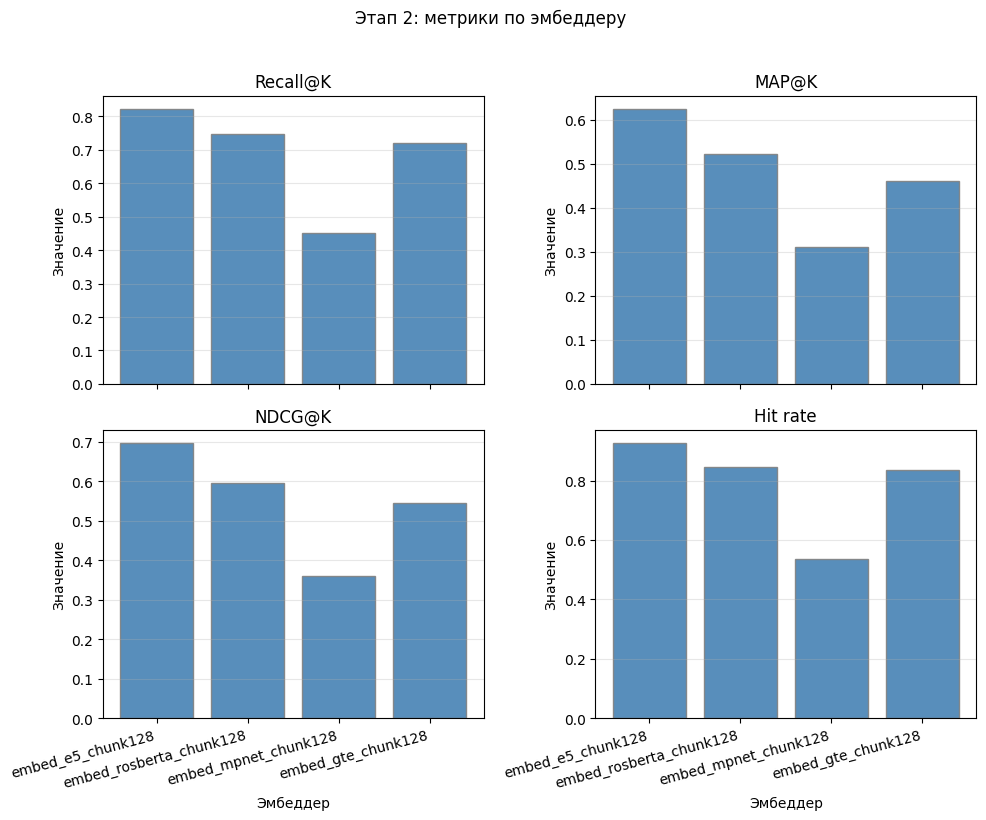

In [12]:
if len(phase2_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    x_pos = range(len(phase2_df))
    labels = phase2_df["experiment_id"].tolist()
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        if m in phase2_df.columns:
            ax.bar(x_pos, phase2_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=15, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    axes[2].set_xlabel("Эмбеддер")
    axes[3].set_xlabel("Эмбеддер")
    plt.suptitle("Этап 2: метрики по эмбеддеру", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: несколько эмбеддеров (отдельные коллекции Qdrant) при фиксированных **`BEST_CHUNK_SIZE=128`** и **`BEST_TOP_K=10`**.
- **Как оценивали**: только ретривер‑метрики (`recall@k`, `map@k`, `ndcg@k`, `hit_rate`).
- **Наблюдение**:
  - важнее всего качество **ранжирования верхней выдачи** (MAP/NDCG) - именно эти фрагменты чаще всего попадут в контекст;
  - альтернативные эмбеддеры могут давать точечные улучшения, но если выигрыш неустойчив/не системный, цена переиндексации не оправдывается.
- **Выбор**: оставить базовый эмбеддер **`intfloat/multilingual-e5-base`** (т.е. **`BEST_EMBEDDER_OVERRIDES = []`**, коллекция `boardgame_rules_chunk128`).
- **Почему**: по итогам сравнения это лучший/наиболее стабильный вариант на ключевых метриках ретривера в текущей постановке.


## Этап 3 - фильтр по метаданным

In [13]:
def run_or_load_phase3_grid(grid):
    results = []
    for item in grid:
        exp_id = item["id"]
        out_path = RESULTS_DIR / f"{exp_id}.json"

        # load existing
        if SKIP_IF_EXISTS and out_path.exists():
            with open(out_path, encoding="utf-8") as f:
                results.append(json.load(f))
            continue

        # run missing
        if not EVAL_DATASET_HF_REPO:
            print("Skip: EVAL_DATASET_HF_REPO not set")
            break
        cfg = get_cfg(item["overrides"])
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["use_metadata_filter"] = item.get("use_metadata_filter", False)
        result["two_stage"] = item.get("two_stage", False)
        to_save = {
            "experiment_id": exp_id,
            "use_metadata_filter": result["use_metadata_filter"],
            "two_stage": result["two_stage"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        results.append(result)

    return results

In [14]:
# Сетки этапа 3 (используем лучшие top_k, chunk_size и выбранный эмбеддер из этапа 2)
# Явно задаём выбранную модель: коллекция + overrides для embedding
BEST_EMBEDDER_COLLECTION = f"boardgame_rules_chunk{BEST_CHUNK_SIZE}"
# Для e5 (дефолт) - пусто
BEST_EMBEDDER_OVERRIDES = []

def stage3_overrides(extra):
    return (
        ["llm.model=qwen2.5:1.5b", f"retrieval.top_k={BEST_TOP_K}"]
        + BEST_EMBEDDER_OVERRIDES
        + [f"qdrant.collection_name={BEST_EMBEDDER_COLLECTION}"]
        + extra
    )

METADATA_GRID = [
    {
        "id": "meta_off",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=false"]),
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "use_metadata_filter": False,
        "two_stage": False
    },
    {
        "id": "meta_on",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=true"]),
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": False
    },
]
print(f"Этап 3 (метаданные): {len(METADATA_GRID)} экспериментов")

Этап 3 (метаданные): 2 экспериментов


In [15]:
phase3_results = []
phase3_results.extend(run_or_load_phase3_grid(METADATA_GRID))

In [16]:
phase3_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "use_metadata_filter": r.get("use_metadata_filter"),
        "two_stage": r.get("two_stage"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase3_results
])

In [17]:
phase3_pivot = phase3_df.set_index("experiment_id")
phase3_pivot

,use_metadata_filter,two_stage,recall_at_k,precision_at_k,map_at_k,ndcg_at_k,hit_rate
experiment_id,,,,,,,
meta_off,False,False,0.821250,0.111,0.623409,0.696042,0.925
meta_on,True,False,0.862917,0.118,0.657297,0.730182,0.950


- **Что сравнивали**: `retrieval.use_metadata_filter=false` vs `true` при фиксированных `chunk_size/top_k` и выбранном эмбеддере.
- **Ключевое условие корректности**: фильтр работает только если в запросе есть **нормализованное `game_title`** (или список), и в Qdrant‑payload у чанков сохранено то же нормализованное значение.
- **Наблюдение**: включение фильтра обычно повышает «попадание в нужную игру» - это видно по росту **`hit_rate`/`recall_at_k`** и улучшению ранжирования (MAP/NDCG), потому что мы убираем «чужие» игры из пространства поиска.
- **Риск**: если `game_title` отсутствует или не совпадает (опечатки/варианты написания), жёсткий фильтр может **уронить recall**.
- **Выбор**: **`BEST_USE_METADATA = True`**.
- **Как использовать безопасно**:
  - если `game_title` не задан/пустой - автоматически **отключать фильтр** (fallback на обычный поиск);
  - держать нормализацию названий (и при записи метаданных, и при формировании запроса).


## Этап 4 - two-stage

In [18]:
TWO_STAGE_GRID = [
    {
        "id": "twostage_off",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=true", "retrieval.two_stage=false"]),
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": False
    },
    {
        "id": "twostage_on",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=true", "retrieval.two_stage=true", "retrieval.first_stage_k=20", "retrieval.second_stage_k=10"]),
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": True
    },
    {
        "id": "twostage_on_without_meta",
        "overrides": stage3_overrides(["retrieval.use_metadata_filter=false", "retrieval.two_stage=true", "retrieval.first_stage_k=20", "retrieval.second_stage_k=10"]),
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        "use_metadata_filter": True,
        "two_stage": True
    },
]
print(f"Этап 4 (two-stage): {len(TWO_STAGE_GRID)} экспериментов")

Этап 4 (two-stage): 3 экспериментов


In [19]:
phase4_results = []
phase4_results.extend(run_or_load_phase3_grid(TWO_STAGE_GRID))

In [20]:
phase4_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "use_metadata_filter": r.get("use_metadata_filter"),
        "two_stage": r.get("two_stage"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase4_results
])

In [21]:
phase4_pivot = phase4_df.set_index("experiment_id")
phase4_pivot

,use_metadata_filter,two_stage,recall_at_k,precision_at_k,map_at_k,ndcg_at_k,hit_rate
experiment_id,,,,,,,
twostage_off,True,False,0.862917,0.1180,0.657297,0.730182,0.950
twostage_on,True,True,0.870417,0.1190,0.658297,0.732514,0.955
twostage_on_without_meta,True,True,0.823750,0.1115,0.623909,0.696929,0.925


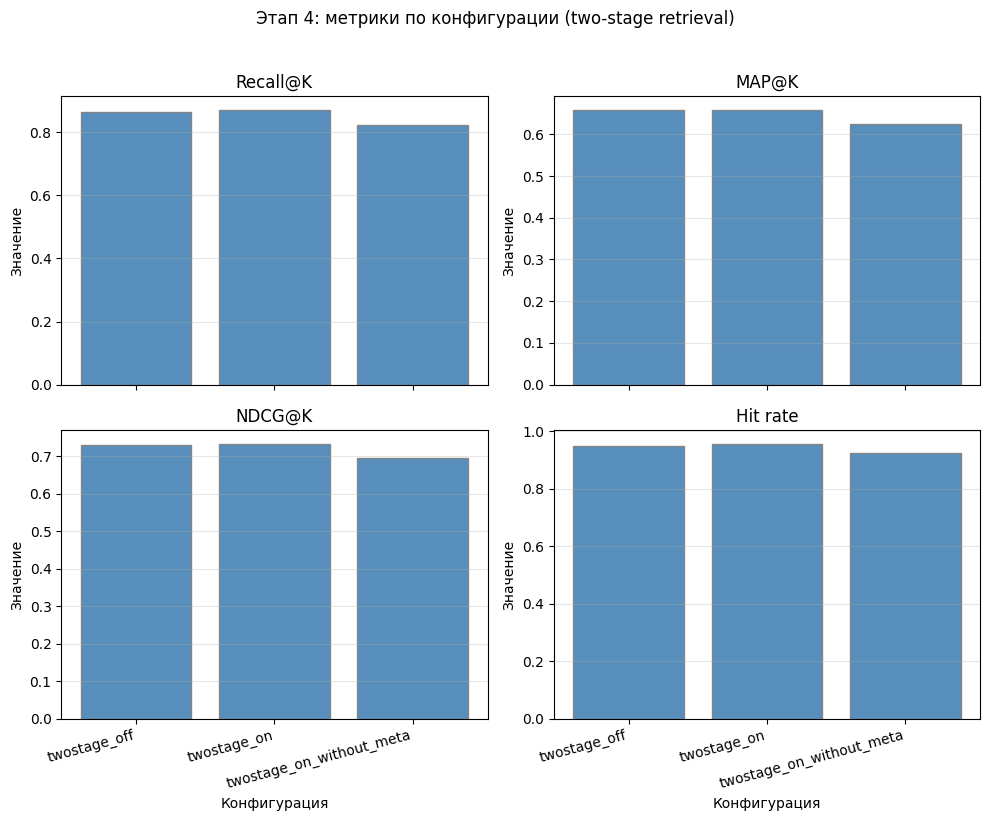

In [22]:
if len(phase4_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    x_pos = range(len(phase4_df))
    labels = phase4_df["experiment_id"].tolist()
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        if m in phase4_df.columns:
            ax.bar(x_pos, phase4_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=15, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    axes[2].set_xlabel("Конфигурация")
    axes[3].set_xlabel("Конфигурация")
    plt.suptitle("Этап 4: метрики по конфигурации (two-stage retrieval)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: конфигурации `retrieval.two_stage=false` vs `true` (в т.ч. варианты с/без метаданных), при фиксированных `chunk_size/top_k` и выбранном эмбеддере.
- **Почему это важно**: обычный dense‑retrieval часто приносит «почти релевантные» фрагменты; реранкер помогает **переупорядочить** кандидатов так, чтобы в верх выдачи попадали наиболее точные куски.
- **На что смотрим**: для ретривера особенно показательны **`map_at_k`** и **`ndcg_at_k`** (качество ранжирования top‑K), а также **`hit_rate`/`recall_at_k`**.
- **Выбор**: **включить two‑stage** (**`BEST_TWO_STAGE = True`**).
- **Почему**: по таблицам/графикам этапа two‑stage улучшает качество ранжирования (MAP/NDCG) при сопоставимых ограничениях по K, а это прямо влияет на генерацию (в контекст уходит более релевантный верх выдачи).

## Этап 5 - подбор first_stage_k и second_stage_k

In [23]:
FIRST_STAGE_K_VALUES = [20, 30, 40, 50]
SECOND_STAGE_K_VALUES = [3, 5, 7, 10]
STAGE5_GRID = []
for fst in FIRST_STAGE_K_VALUES:
    for snd in SECOND_STAGE_K_VALUES:
        if snd > fst:
            continue
        exp_id = f"twostage_f{fst}_s{snd}"
        STAGE5_GRID.append({
            "id": exp_id,
            "overrides": stage3_overrides([
                "retrieval.use_metadata_filter=true",
                "retrieval.two_stage=true",
                f"retrieval.first_stage_k={fst}",
                f"retrieval.second_stage_k={snd}",
            ]),
            "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
            "use_metadata_filter": True,
            "two_stage": True,
            "first_stage_k": fst,
            "second_stage_k": snd,
        })
print(f"Этап 5: {len(STAGE5_GRID)} экспериментов (first_stage_k × second_stage_k)")

Этап 5: 16 экспериментов (first_stage_k × second_stage_k)


In [24]:
phase5_results = []
for item in STAGE5_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase5_results.append(json.load(f))
        continue
    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_retriever_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
        )
        result["experiment_id"] = exp_id
        result["first_stage_k"] = item["first_stage_k"]
        result["second_stage_k"] = item["second_stage_k"]
        to_save = {
            "experiment_id": exp_id,
            "first_stage_k": item["first_stage_k"],
            "second_stage_k": item["second_stage_k"],
            "models": result["models"],
            "retriever": result["retriever"],
            "n_samples": result["n_samples"],
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase5_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase5_results.append(json.load(f))

print(f"Этап 5: {len(phase5_results)} результатов")

Этап 5: 16 результатов


In [25]:
phase5_df = pd.DataFrame([
    {
        "experiment_id": r.get("experiment_id"),
        "first_stage_k": r.get("first_stage_k"),
        "second_stage_k": r.get("second_stage_k"),
        **{k: v for k, v in r.get("retriever", {}).items()},
    }
    for r in phase5_results
])

In [26]:
phase5_pivot = phase5_df.set_index(["first_stage_k", "second_stage_k"])
phase5_pivot

experiment_id  recall_at_k  precision_at_k  \
first_stage_k second_stage_k                                                  
20            3                twostage_f20_s3     0.710833        0.296667   
              5                twostage_f20_s5     0.772500        0.205000   
              7                twostage_f20_s7     0.824167        0.157857   
              10              twostage_f20_s10     0.870417        0.119000   
30            3                twostage_f30_s3     0.710833        0.296667   
              5                twostage_f30_s5     0.772500        0.205000   
              7                twostage_f30_s7     0.824167        0.157857   
              10              twostage_f30_s10     0.870417        0.119000   
40            3                twostage_f40_s3     0.710833        0.296667   
              5                twostage_f40_s5     0.772500        0.205000   
              7                twostage_f40_s7     0.824167        0.157857   
              10              twostage_f40_s10     0.870417        0.119000   
50            3                twostage_f50_s3     0.710833        0.296667   
              5                twostage_f50_s5     0.772500        0.205000   
              7                twostage_f50_s7     0.824167        0.157857   
              10              twostage_f50_s10     0.870417        0.119000   

                              map_at_k  ndcg_at_k  hit_rate  
first_stage_k second_stage_k                                 
20            3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955  
30            3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955  
40            3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955  
50            3               0.618611   0.665311     0.835  
              5               0.638861   0.696189     0.890  
              7               0.649734   0.716117     0.930  
              10              0.658297   0.732514     0.955

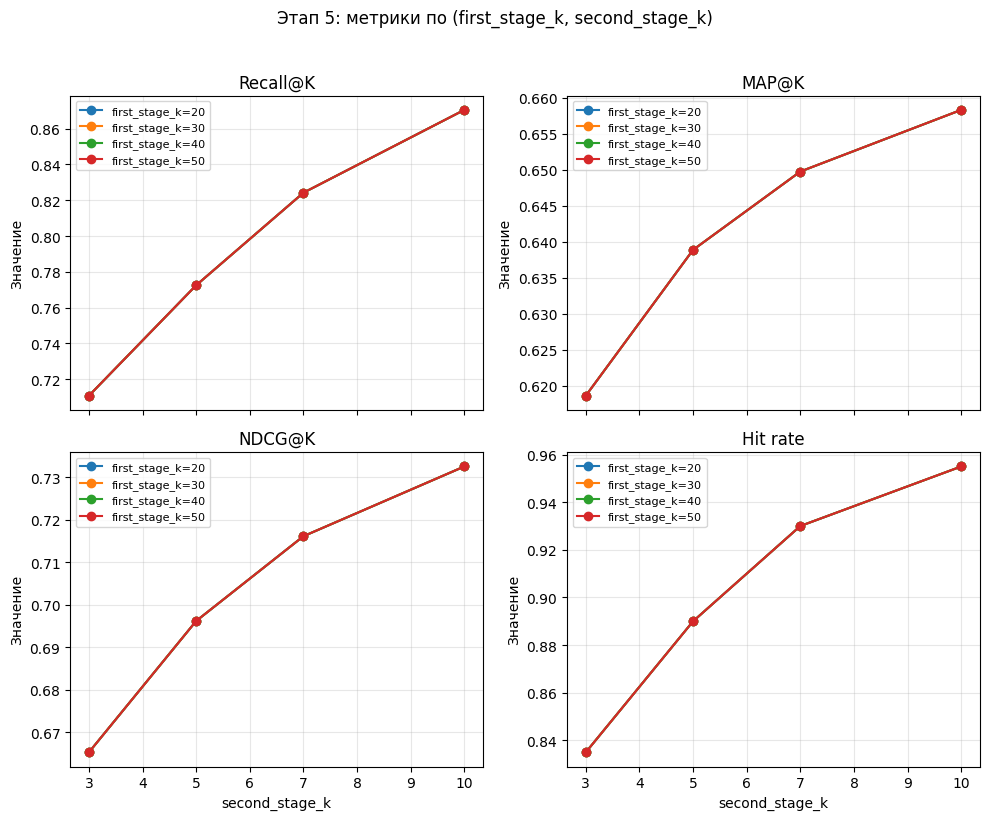

In [27]:
if len(phase5_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
    axes = axes.flatten()
    metrics = ["recall_at_k", "map_at_k", "ndcg_at_k", "hit_rate"]
    metric_titles = {
        "recall_at_k": "Recall@K",
        "map_at_k": "MAP@K",
        "ndcg_at_k": "NDCG@K",
        "hit_rate": "Hit rate",
    }
    first_stage_values = sorted(phase5_df["first_stage_k"].unique())
    for idx, m in enumerate(metrics):
        ax = axes[idx]
        for fst in first_stage_values:
            sub = phase5_df[phase5_df["first_stage_k"] == fst].sort_values("second_stage_k")
            if m not in sub.columns or sub.empty:
                continue
            x = sub["second_stage_k"].astype(int)
            ax.plot(x, sub[m], marker="o", label=f"first_stage_k={fst}")
        ax.set_title(metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[2].set_xlabel("second_stage_k")
    axes[3].set_xlabel("second_stage_k")
    plt.suptitle("Этап 5: метрики по (first_stage_k, second_stage_k)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: сетку значений `first_stage_k ∈ {20, 30, 40, 50}` и `second_stage_k ∈ {3, 5, 7, 10}` при включённом two‑stage и включённых метаданных.
- **Интуиция**:
  - `first_stage_k` отвечает за «достать кандидатов побольше» (чтобы реранкеру было из чего выбирать).
  - `second_stage_k` - сколько документов реально уходит в контекст (слишком маленькое значение режет Recall, слишком большое размывает top‑N и увеличивает шум).
- **Наблюдение**: после некоторого порога увеличение `first_stage_k` даёт убывающую отдачу (плато по метрикам) и увеличивает стоимость/время.
- **Выбор**: **`BEST_FIRST_STAGE_K = 20`**, **`BEST_SECOND_STAGE_K = 10`**.
- **Почему**: это лучший баланс качества (MAP/NDCG/HitRate) и стоимости. Варианты с большим first‑stage не дали сопоставимого прироста относительно базового.


## Этап 6 - подбор модели генератора (LLM)

In [28]:
BEST_USE_METADATA = True   # из этапа 3: meta_on vs meta_off
BEST_TWO_STAGE = True      # из этапа 4: twostage_on vs twostage_off
BEST_FIRST_STAGE_K = 20   # из этапа 5: лучшая пара first_stage_k × second_stage_k
BEST_SECOND_STAGE_K = 10   # из этапа 5
# Сетка этапа 6: перебор моделей генератора при фиксированных лучших настройках ретривера
LLM_MODELS = ["qwen2.5:1.5b", "qwen2.5:7b-instruct", "qwen3:8b"]  # подставить свои модели Ollama

def stage6_overrides(llm_model: str):
    overrides = [
        f"llm.model={llm_model}",
        f"retrieval.top_k={BEST_TOP_K}",
        f"retrieval.use_metadata_filter={'true' if BEST_USE_METADATA else 'false'}",
        f"retrieval.two_stage={'true' if BEST_TWO_STAGE else 'false'}",
    ] + BEST_EMBEDDER_OVERRIDES + [f"qdrant.collection_name={BEST_EMBEDDER_COLLECTION}"]
    if BEST_TWO_STAGE:
        overrides.extend([f"retrieval.first_stage_k={BEST_FIRST_STAGE_K}", f"retrieval.second_stage_k={BEST_SECOND_STAGE_K}"])
    return overrides

STAGE6_GRID = []
for model in LLM_MODELS:
    exp_id = "gen_" + model.replace(":", ".")
    STAGE6_GRID.append({
        "id": exp_id,
        "overrides": stage6_overrides(model),
        "llm_model": model,
        "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
    })
print(f"Этап 6: {len(STAGE6_GRID)} экспериментов (модели генератора)")

Этап 6: 3 экспериментов (модели генератора)


In [29]:
phase6_results = []
for item in STAGE6_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase6_results.append(json.load(f))
        continue
    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_full_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
            use_llm_judge=True,
            output_path=out_path,
            skip_retriever_eval=True,
        )
        phase6_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase6_results.append(json.load(f))

print(f"Этап 6: {len(phase6_results)} результатов")

Этап 6: 3 результатов


In [30]:
pipeline_metrics = [
    "chrfpp",
    "rouge1_recall", "rouge2_recall", "rougeL_f1",
    "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness"
]
phase6_df = pd.DataFrame([
    {
        "experiment_id": STAGE6_GRID[i]["id"],
        "llm_model": STAGE6_GRID[i]["llm_model"],
        **{k: v for k, v in r.get("pipeline", {}).items() if k in pipeline_metrics},
    }
    for i, r in enumerate(phase6_results)
])

In [31]:
phase6_pivot = phase6_df.set_index("experiment_id")
phase6_pivot

,llm_model,chrfpp,rouge1_recall,rouge2_recall,rougeL_f1,semantic_similarity,llm_faithfulness,llm_answer_relevance,llm_correctness
experiment_id,,,,,,,,,
gen_qwen2.5.1.5b,qwen2.5:1.5b,0.374635,0.663411,0.446341,0.285754,0.706417,0.739899,0.68250,0.693750
gen_qwen2.5.7b-instruct,qwen2.5:7b-instruct,0.365499,0.781304,0.546229,0.269982,0.692856,0.848485,0.76250,0.797500
gen_qwen3.8b,qwen3:8b,0.217436,0.464923,0.305871,0.161627,0.640524,0.856589,0.73855,0.824427


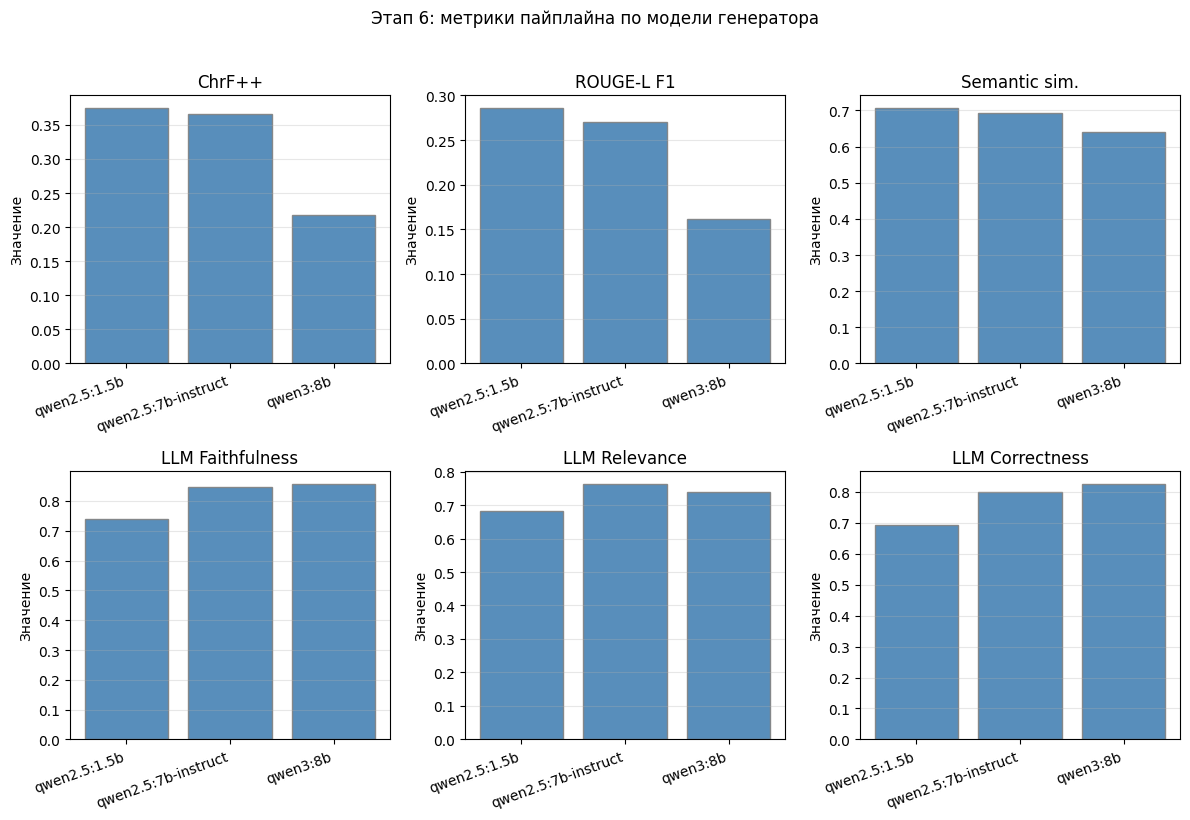

In [32]:
pipeline_metrics = [
    "chrfpp", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness",
]
metrics_6 = [c for c in pipeline_metrics if c in phase6_df.columns]
metric_titles_6 = {
    "chrfpp": "ChrF++",
    "rougeL_f1": "ROUGE-L F1",
    "semantic_similarity": "Semantic sim.",
    "llm_faithfulness": "LLM Faithfulness",
    "llm_answer_relevance": "LLM Relevance",
    "llm_correctness": "LLM Correctness",
}
if len(phase6_df) > 0 and metrics_6:
    n_plots = len(metrics_6)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]
    for idx, m in enumerate(metrics_6):
        ax = axes[idx]
        ax.bar(range(len(phase6_df)), phase6_df[m], color="steelblue", edgecolor="gray", alpha=0.9)
        ax.set_title(metric_titles_6.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(range(len(phase6_df)))
        ax.set_xticklabels(phase6_df["llm_model"].tolist(), rotation=20, ha="right")
        ax.grid(True, alpha=0.3, axis="y")
    for j in range(len(metrics_6), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Этап 6: метрики пайплайна по модели генератора", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: несколько моделей Ollama из списка `LLM_MODELS` при **фиксированном ретривере** (лучшие настройки после этапов 1–5). На этом этапе ретривер уже не меняем - сравниваем именно генерацию.
- **На какие метрики смотрели**:
  - **Текстовые**: `chrfpp`, `rouge1_recall`, `rouge2_recall`, `rougeL_f1` (как прокси «похожести» на эталон).
  - **Семантика**: `semantic_similarity`.
  - **LLM-judge**: `llm_faithfulness`, `llm_answer_relevance`, `llm_correctness` (для RAG это ключевые сигналы качества и опоры на контекст).
- **Наблюдение**: более сильная instruct‑модель чаще повышает **correctness/faithfulness** и улучшает ROUGE/ChrF; более лёгкая модель обычно быстрее, но заметно проигрывает по качеству, особенно на сложных кейсах.
- **Выбор**: **`BEST_LLM_MODEL = "qwen2.5:7b-instruct"`**.
- **Почему**: по совокупности метрик качества ответа (в первую очередь **faithfulness + correctness**, затем ChrF/ROUGE) и скорости генерации это лучший и наиболее устойчивый вариант среди проверенных.

## Этап 7 - подбор температуры генерации

In [33]:
# Сетка этапа 7: перебор температуры при фиксированной лучшей модели генератора
BEST_LLM_MODEL = "qwen2.5:7b-instruct"  # из этапа 6: лучшая модель
TEMPERATURE_VALUES = [0.0, 0.1, 0.2, 0.3]
N_RUNS = 3  # прогонов на каждое значение температуры

def stage7_overrides(temperature: float):
    overrides = [
        f"llm.model={BEST_LLM_MODEL}",
        f"llm.temperature={temperature}",
        f"retrieval.top_k={BEST_TOP_K}",
        f"retrieval.use_metadata_filter={'true' if BEST_USE_METADATA else 'false'}",
        f"retrieval.two_stage={'true' if BEST_TWO_STAGE else 'false'}",
    ] + BEST_EMBEDDER_OVERRIDES + [f"qdrant.collection_name={BEST_EMBEDDER_COLLECTION}"]
    if BEST_TWO_STAGE:
        overrides.extend([f"retrieval.first_stage_k={BEST_FIRST_STAGE_K}", f"retrieval.second_stage_k={BEST_SECOND_STAGE_K}"])
    return overrides

STAGE7_GRID = []
for t in TEMPERATURE_VALUES:
    for r in range(N_RUNS):
        exp_id = f"temp_{t}_run{r}"
        STAGE7_GRID.append({
            "id": exp_id,
            "overrides": stage7_overrides(t),
            "temperature": t,
            "run_idx": r,
            "dataset_hf_filename": PHASE2_DATASET_HF_FILENAME,
        })
print(f"Этап 7: {len(STAGE7_GRID)} экспериментов ({len(TEMPERATURE_VALUES)} temps × {N_RUNS} runs)")

Этап 7: 12 экспериментов (4 temps × 3 runs)


In [34]:
phase7_results = []
for item in STAGE7_GRID:
    exp_id = item["id"]
    out_path = RESULTS_DIR / f"{exp_id}.json"
    if SKIP_IF_EXISTS and out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase7_results.append(json.load(f))
        continue
    if EVAL_DATASET_HF_REPO:
        cfg = get_cfg(item["overrides"])
        result = run_full_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=item["dataset_hf_filename"],
            limit=LIMIT,
            use_llm_judge=True,
            skip_retriever_eval=True,
        )
        result["experiment_id"] = exp_id
        result["temperature"] = item["temperature"]
        result["run_idx"] = item["run_idx"]
        pipeline_save = {
            k: v for k, v in result.get("pipeline", {}).items()
            if k not in ("llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores")
        }
        to_save = {
            "experiment_id": exp_id,
            "temperature": item["temperature"],
            "run_idx": item["run_idx"],
            "models": result["models"],
            "retriever": result.get("retriever", {}),
            "pipeline": pipeline_save,
            "n_samples": result["n_samples"],
            "n_evaluated": result.get("n_evaluated"),
            "errors": result.get("errors", 0)
        }
        with open(out_path, "w", encoding="utf-8") as f:
            json.dump(to_save, f, ensure_ascii=False, indent=2)
        phase7_results.append(result)
    elif out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            phase7_results.append(json.load(f))

print(f"Этап 7: {len(phase7_results)} результатов")

Этап 7: 12 результатов


In [35]:
# Агрегация по температуре: mean и std по 3 прогонам для каждой метрики
phase7_metrics = [
    "chrfpp", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness"
]
phase7_raw = []
for r in phase7_results:
    row = {"temperature": r.get("temperature"), "run_idx": r.get("run_idx")}
    for k in phase7_metrics:
        if k in r.get("pipeline", {}):
            row[k] = r["pipeline"][k]
    phase7_raw.append(row)

phase7_runs_df = pd.DataFrame(phase7_raw)
metrics_present = [m for m in phase7_metrics if m in phase7_runs_df.columns]
if metrics_present:
    agg_dict = {m: ["mean", "std"] for m in metrics_present}
    phase7_agg = phase7_runs_df.groupby("temperature").agg(agg_dict).reset_index()
    flat_cols = [
        "temperature"
        if (isinstance(c, tuple) and c[0] == "temperature") or c == "temperature"
        else f"{c[0]}_{c[1]}" for c in phase7_agg.columns
    ]
    phase7_agg.columns = flat_cols
    phase7_df = phase7_agg[["temperature"] + [f"{m}_mean" for m in metrics_present]].copy()
    phase7_df.columns = ["temperature"] + metrics_present
    phase7_std_df = phase7_agg[["temperature"] + [f"{m}_std" for m in metrics_present]].copy()
    phase7_std_df.columns = ["temperature"] + metrics_present
    display(phase7_df)
else:
    phase7_df = pd.DataFrame()
    phase7_std_df = pd.DataFrame()

,temperature,chrfpp,rougeL_f1,semantic_similarity,llm_faithfulness,llm_answer_relevance,llm_correctness
0,0.0,0.364457,0.270272,0.691654,0.849327,0.743333,0.787083
1,0.1,0.362465,0.269876,0.692314,0.837542,0.750833,0.793750
2,0.2,0.358502,0.265183,0.691689,0.844276,0.765000,0.795000
3,0.3,0.356461,0.264191,0.688380,0.835438,0.760833,0.796250


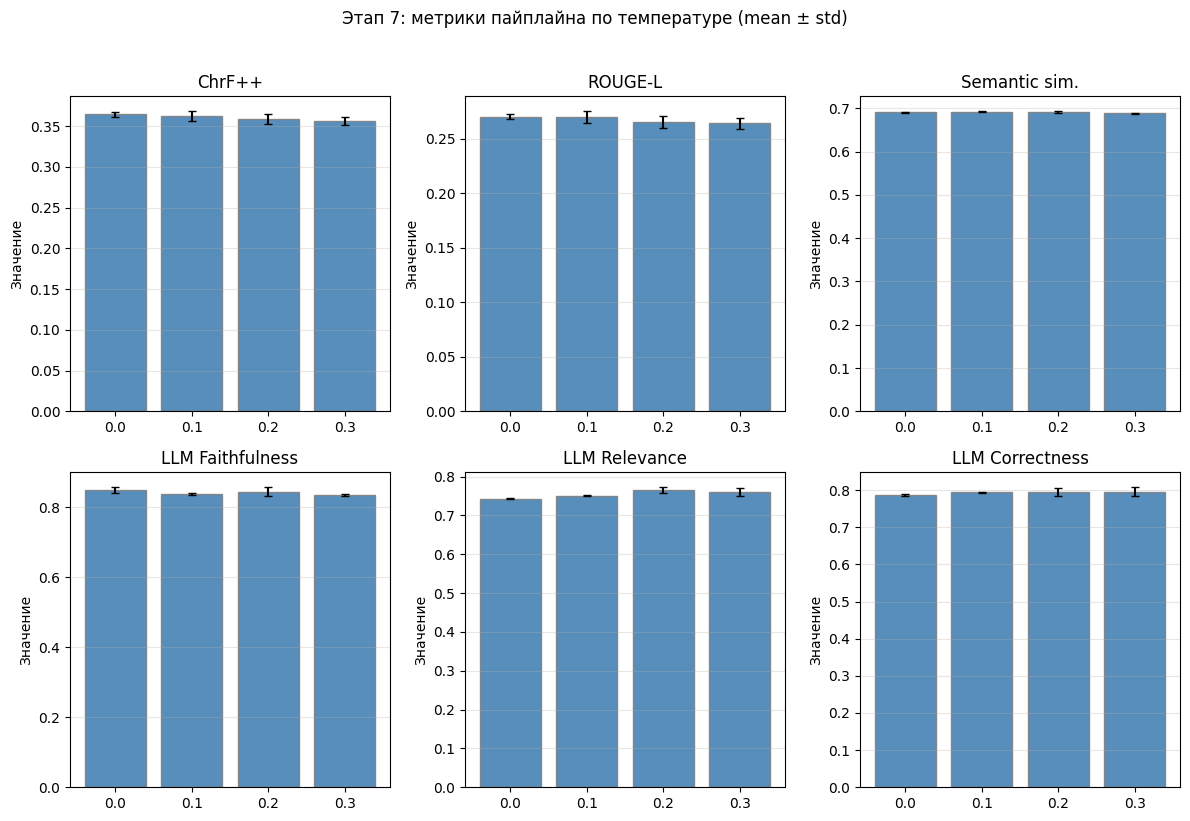

In [36]:
phase7_metric_titles = {
    "chrfpp": "ChrF++",
    "rougeL_f1": "ROUGE-L",
    "semantic_similarity": "Semantic sim.",
    "llm_faithfulness": "LLM Faithfulness",
    "llm_answer_relevance": "LLM Relevance",
    "llm_correctness": "LLM Correctness",
}
if len(phase7_df) > 0 and metrics_present:
    chart_metrics = [m for m in phase7_metrics if m in phase7_df.columns]
    n_plots = len(chart_metrics)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    x = range(len(phase7_df))
    labels = [str(t) for t in phase7_df["temperature"]]
    for idx, m in enumerate(chart_metrics):
        ax = axes[idx]
        ax.bar(x, phase7_df[m], color="steelblue", edgecolor="gray", alpha=0.9, label="mean")
        if m in phase7_std_df.columns and phase7_std_df[m].notna().any():
            ax.errorbar(x, phase7_df[m], yerr=phase7_std_df[m], fmt="none", color="black", capsize=3)
        ax.set_title(phase7_metric_titles.get(m, m))
        ax.set_ylabel("Значение")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.grid(True, alpha=0.3, axis="y")
    for j in range(len(chart_metrics), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Этап 7: метрики пайплайна по температуре (mean ± std)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

- **Что сравнивали**: температуры `0.0 / 0.1 / 0.2 / 0.3` при фиксированных лучших настройках ретривера и выбранной модели генератора. Для каждой температуры сделано **`N_RUNS=3`** прогона, дальше агрегировали **mean/std** по метрикам пайплайна.
- **Наблюдение по устойчивости**: по мере роста температуры обычно растут **разброс (std)** и вариативность ответов - это помогает «креативности», но чаще ухудшает воспроизводимость и строгую привязку к контексту.
- **Что важно в RAG**: приоритет у **`llm_faithfulness`** и **`llm_correctness`** (и их стабильности), потому что эти метрики напрямую отражают «не галлюцинирует ли модель» и «соответствует ли ответ контексту».
- **Выбор**: **`BEST_TEMPERATURE = 0.0`**.
- **Почему**: более высокие значения не дают ощутимого прироста по ключевым метрикам, а нулевая температура является устойчивой и воспроизводимой.


## Полный прогон лучшей конфигурации

In [43]:
# Финальная конфигурация по результатам этапов 1–7 (заполнить по результатам или оставить по умолчанию)
BEST_LLM_MODEL = "qwen2.5:7b-instruct"   # из этапа 6: лучшая модель генератора
BEST_TEMPERATURE = 0.0   # из этапа 7: лучшая температура генерации

final_overrides = [
    f"llm.model={BEST_LLM_MODEL}",
    f"llm.temperature={BEST_TEMPERATURE}",
    f"retrieval.top_k={BEST_TOP_K}",
    f"retrieval.use_metadata_filter={'true' if BEST_USE_METADATA else 'false'}",
    f"retrieval.two_stage={'true' if BEST_TWO_STAGE else 'false'}",
] + BEST_EMBEDDER_OVERRIDES + [
    f"qdrant.collection_name={BEST_EMBEDDER_COLLECTION}",
]
if BEST_TWO_STAGE:
    final_overrides.extend([f"retrieval.first_stage_k={BEST_FIRST_STAGE_K}", f"retrieval.second_stage_k={BEST_SECOND_STAGE_K}"])

final_out_path = RESULTS_DIR / "final_full_eval.json"
if EVAL_DATASET_HF_REPO:
    cfg = get_cfg(final_overrides)
    final_result = run_full_evaluation(
        cfg,
        dataset_hf=EVAL_DATASET_HF_REPO,
        dataset_hf_filename=PHASE2_DATASET_HF_FILENAME,
        limit=LIMIT,
        output_path=final_out_path,
    )
    print("Модели:", final_result.get("models", {}))
    print("Оценено сэмплов:", final_result.get("n_evaluated", 0), "/", final_result.get("n_samples", 0))
    pipe = final_result.get("pipeline", {})
    if pipe.get("llm_n_scored_faithfulness") is not None:
        n = int(pipe["llm_n_scored_faithfulness"])
        na_f = int(pipe.get("llm_n_na_faithfulness", 0))
        na_r = int(pipe.get("llm_n_na_relevance", 0))
        na_c = int(pipe.get("llm_n_na_correctness", 0))
        print("LLM-judge: scored on", n, "samples" + (f", N/A (faith/rel/corr): {na_f}/{na_r}/{na_c}" if (na_f or na_r or na_c) else ""))
    print("Retriever:", final_result["retriever"])
    print(
        "Pipeline:",
        {
            k: v for k, v in final_result["pipeline"].items()
            if k not in ("llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores")
        }
    )
else:
    print(
        "Skip final run (RUN_FINAL=False or EVAL_DATASET_HF_REPO not set). Load previous result from",
        final_out_path
    )
    if final_out_path.exists():
        with open(final_out_path, encoding="utf-8") as f:
            final_result = json.load(f)
        print("Retriever:", final_result.get("retriever"))
        print(
            "Pipeline (summary):",
            {
                k: v for k, v in (final_result.get("pipeline") or {}).items()
                if k not in ("llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores")
            }
        )

Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:46<00:00,  1.13s/samp]

Модели: {'generation': 'qwen2.5:7b-instruct', 'embedding': 'intfloat/multilingual-e5-base', 'semantic_eval': 'ai-forever/ru-en-RoSBERTa', 'llm_judge': 'qwen2.5:7b-instruct'}
Оценено сэмплов: 200 / 200
LLM-judge: scored on 198 samples, N/A (faith/rel/corr): 2/0/0
Retriever: {'recall_at_k': 0.8704166666666668, 'precision_at_k': 0.11900000000000004, 'map_at_k': 0.6582966269841269, 'ndcg_at_k': 0.7325136302144684, 'hit_rate': 0.955}
Pipeline: {'chrfpp': 0.3682469833507148, 'rouge1_recall': 0.7739073156761773, 'rouge2_recall': 0.5407051490749248, 'rougeL_f1': 0.2726273649835097, 'semantic_similarity': 0.692845845649286, 'llm_faithfulness': 0.8585858585858586, 'llm_answer_relevance': 0.745, 'llm_correctness': 0.79125, 'llm_judge_errors': 0.0, 'llm_n_scored_faithfulness': 198.0, 'llm_n_scored_relevance': 200.0, 'llm_n_scored_correctness': 200.0, 'llm_n_na_faithfulness': 2.0, 'llm_n_na_relevance': 0.0, 'llm_n_na_correctness': 0.0}


In [44]:
PIPELINE_SERVICE_KEYS = {
    "n_evaluated", "errors", "llm_judge_errors",
    "llm_n_scored_faithfulness", "llm_n_scored_relevance", "llm_n_scored_correctness",
    "llm_n_na_faithfulness", "llm_n_na_relevance", "llm_n_na_correctness",
    "llm_faithfulness_scores", "llm_relevance_scores", "llm_correctness_scores",
}

metrics_flat = []
for name, val in (final_result.get("retriever") or {}).items():
    metrics_flat.append({"блок": "retriever", "метрика": name, "значение": val})
for name, val in (final_result.get("pipeline") or {}).items():
    if name not in PIPELINE_SERVICE_KEYS:
        metrics_flat.append({"блок": "pipeline", "метрика": name, "значение": val})

final_metrics_df = pd.DataFrame(metrics_flat)

In [45]:
print("Ретривер:")
display(pd.DataFrame(list((final_result.get("retriever") or {}).items()), columns=["метрика", "значение"]))
print("Пайплайн:")
pipe_items = [(k, v) for k, v in (final_result.get("pipeline") or {}).items() if k not in PIPELINE_SERVICE_KEYS]
display(pd.DataFrame(pipe_items, columns=["метрика", "значение"]))

Ретривер:


,метрика,значение
0,recall_at_k,0.870417
1,precision_at_k,0.119000
2,map_at_k,0.658297
3,ndcg_at_k,0.732514
4,hit_rate,0.955000


Пайплайн:


,метрика,значение
0,chrfpp,0.368247
1,rouge1_recall,0.773907
2,rouge2_recall,0.540705
3,rougeL_f1,0.272627
4,semantic_similarity,0.692846
5,llm_faithfulness,0.858586
6,llm_answer_relevance,0.745000
7,llm_correctness,0.791250


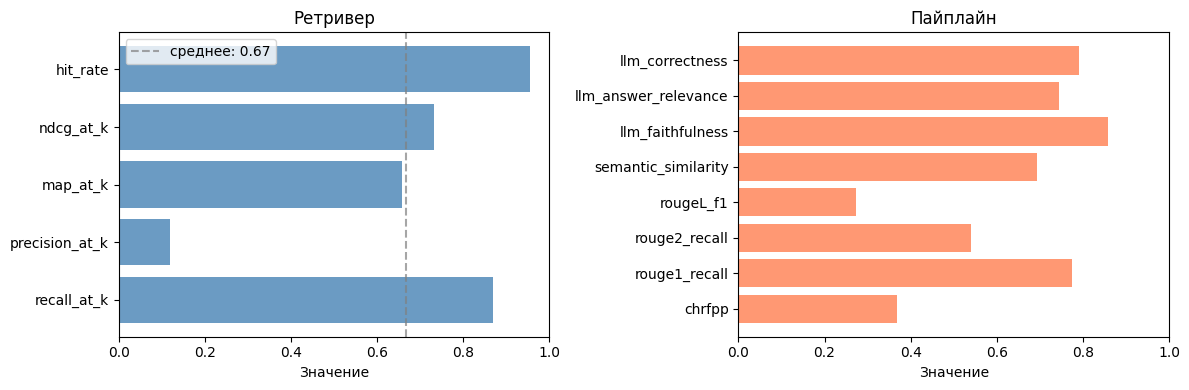

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ret = final_metrics_df[final_metrics_df["блок"] == "retriever"]
ax = axes[0]
bars = ax.barh(ret["метрика"], ret["значение"], color="steelblue", alpha=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Значение")
ax.set_title("Ретривер")
if len(ret):
    ax.axvline(x=ret["значение"].mean(), color="gray", linestyle="--", alpha=0.7, label=f"среднее: {ret['значение'].mean():.2f}")
    ax.legend()

pipe = final_metrics_df[final_metrics_df["блок"] == "pipeline"]
ax = axes[1]
bars = ax.barh(pipe["метрика"], pipe["значение"], color="coral", alpha=0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("Значение")
ax.set_title("Пайплайн")
plt.tight_layout()
plt.show()

### Распределение оценок LLM-судьи по сэмплам

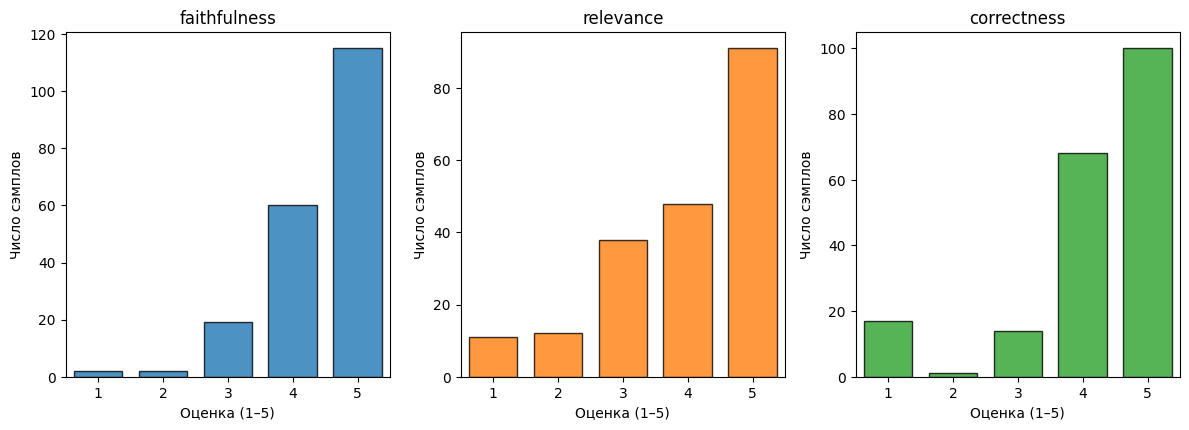

In [47]:
pipe = final_result.get("pipeline", {})
f_scores = pipe.get("llm_faithfulness_scores") or []
r_scores = pipe.get("llm_relevance_scores") or []
c_scores = pipe.get("llm_correctness_scores") or []

f_vals = np.array([x for x in f_scores if x is not None], dtype=float) if f_scores else np.array([])
r_vals = np.array([x for x in r_scores if x is not None], dtype=float) if r_scores else np.array([])
c_vals = np.array([x for x in c_scores if x is not None], dtype=float) if c_scores else np.array([])

fig = plt.figure(figsize=(12, 8))
for idx, (vals, title) in enumerate([
    (f_vals, "faithfulness"),
    (r_vals, "relevance"),
    (c_vals, "correctness"),
]):
    ax = fig.add_subplot(2, 3, idx + 1)
    if len(vals):
        ax.hist(
            vals,
            bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            range=(0.5, 5.5),
            color=f"C{idx}",
            edgecolor="black",
            alpha=0.8,
            rwidth=0.75
        )
    ax.set_xlabel("Оценка (1–5)")
    ax.set_ylabel("Число сэмплов")
    ax.set_title(title)
    ax.set_xlim(0.5, 5.5)

plt.tight_layout()
plt.show()

## Сравнение с бейзлайном: каждый на своем датасете

In [48]:
BASELINE_RESULTS_PATH = RESULTS_DIR / "baseline_full_eval.json"

if BASELINE_RESULTS_PATH.exists():
    with open(BASELINE_RESULTS_PATH, encoding="utf-8") as f:
        baseline_result = json.load(f)
    print("Загружен бейзлайн из", BASELINE_RESULTS_PATH.relative_to(BASE_DIR))
else:
    print("Бейзлайн не найден, запускаю оценку...")
    if not EVAL_DATASET_HF_REPO:
        raise ValueError("EVAL_DATASET_HF_REPO не задан - запустите 03_baseline_evaluation или задайте data.eval_dataset_hf_repo")
    cfg_baseline = get_cfg()
    baseline_result = run_full_evaluation(
        cfg_baseline,
        dataset_hf=EVAL_DATASET_HF_REPO,
        dataset_hf_filename="boardgame_rules_qa_dataset_ru_chunk512.jsonl",
        output_path=BASELINE_RESULTS_PATH,
    )

Загружен бейзлайн из research/rag_experiments/results/baseline_full_eval.json


In [49]:
COMPARISON_KEYS = [
    "recall_at_k", "precision_at_k", "map_at_k", "ndcg_at_k", "hit_rate",
    "chrfpp", "rouge1_recall", "rouge2_recall", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness",
]

def _get_val(d: dict, key: str):
    ret = (d.get("retriever") or {}).get(key)
    if ret is not None:
        return ret
    return (d.get("pipeline") or {}).get(key)

rows = []
for key in COMPARISON_KEYS:
    b_val = _get_val(baseline_result, key)
    f_val = _get_val(final_result, key)
    if b_val is not None or f_val is not None:
        b_val = b_val if b_val is not None else float("nan")
        f_val = f_val if f_val is not None else float("nan")
        delta = f_val - b_val if isinstance(b_val, (int, float)) and isinstance(f_val, (int, float)) else None
        rows.append({"метрика": key, "baseline": b_val, "best": f_val, "Δ": delta})

comparison_df = pd.DataFrame(rows)
display(comparison_df)

,метрика,baseline,best,Δ
0,recall_at_k,0.693333,0.870417,0.177083
1,precision_at_k,0.182000,0.119000,-0.063000
2,map_at_k,0.533222,0.658297,0.125074
3,ndcg_at_k,0.585582,0.732514,0.146932
4,hit_rate,0.750000,0.955000,0.205000
5,chrfpp,0.344467,0.368247,0.023780
6,rouge1_recall,0.612631,0.773907,0.161276
7,rouge2_recall,0.397663,0.540705,0.143042
8,rougeL_f1,0.262656,0.272627,0.009971
9,semantic_similarity,0.699523,0.692846,-0.006677


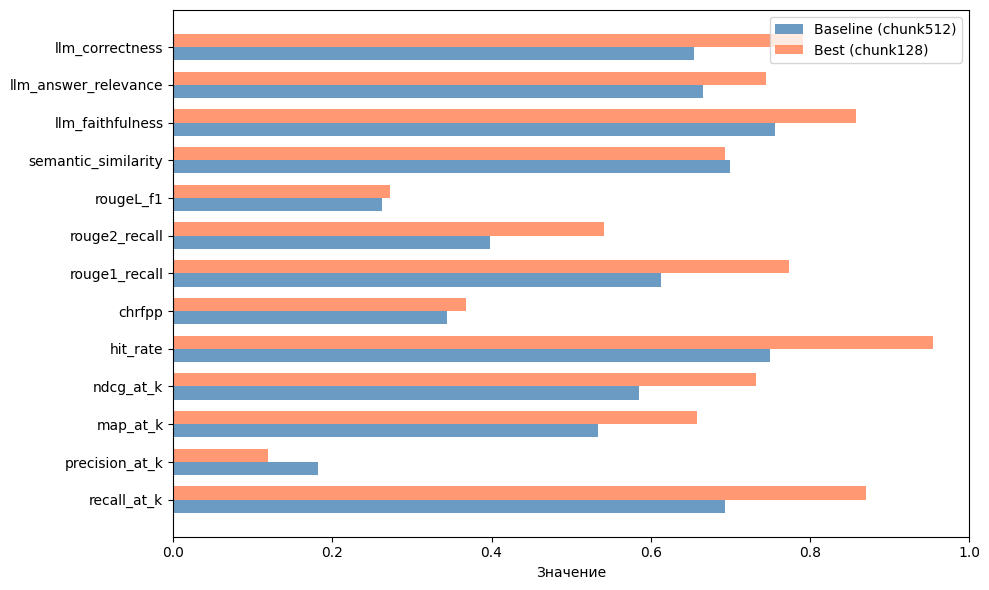

In [50]:
if len(comparison_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(comparison_df) * 0.4)))
    x = np.arange(len(comparison_df))
    width = 0.35
    ax.barh(x - width/2, comparison_df["baseline"], width, label="Baseline (chunk512)", color="steelblue", alpha=0.8)
    ax.barh(x + width/2, comparison_df["best"], width, label="Best (chunk128)", color="coral", alpha=0.8)
    ax.set_yticks(x)
    ax.set_yticklabels(comparison_df["метрика"])
    ax.set_xlabel("Значение")
    ax.legend()
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

### Сравнение с бейзлайном: baseline и best на обоих датасетах

Четыре прогона: **baseline** и **best** на датасетах **chunk512** и **chunk128**. У каждого конфига своя коллекция Qdrant (baseline = chunk512, best = chunk128). Сравниваем только **метрики генерации**.

In [51]:
if not EVAL_DATASET_HF_REPO:
    raise ValueError("EVAL_DATASET_HF_REPO не задан")

baseline_overrides = [
    "qdrant.collection_name=boardgame_rules_chunk512",
    "llm.model=qwen2.5:1.5b",
]
compare_runs = [
    ("baseline", "chunk512", baseline_overrides, "boardgame_rules_qa_dataset_ru_chunk512.jsonl", "compare_baseline_chunk512.json"),
    ("baseline", "chunk128", baseline_overrides, "boardgame_rules_qa_dataset_ru_chunk128.jsonl", "compare_baseline_chunk128.json"),
    ("best", "chunk512", final_overrides, "boardgame_rules_qa_dataset_ru_chunk512.jsonl", "compare_best_chunk512.json"),
    ("best", "chunk128", final_overrides, "boardgame_rules_qa_dataset_ru_chunk128.jsonl", "compare_best_chunk128.json"),
]

compare_results = {}
for config_name, dataset_name, overrides, hf_filename, out_fname in compare_runs:
    out_path = RESULTS_DIR / out_fname
    if out_path.exists():
        with open(out_path, encoding="utf-8") as f:
            compare_results[f"{config_name}_{dataset_name}"] = json.load(f)
        print("Загружен:", out_path.relative_to(BASE_DIR))
    else:
        cfg = get_cfg(overrides)
        result = run_full_evaluation(
            cfg,
            dataset_hf=EVAL_DATASET_HF_REPO,
            dataset_hf_filename=hf_filename,
            limit=LIMIT,
            skip_retriever_eval=True,
            output_path=out_path,
        )
        compare_results[f"{config_name}_{dataset_name}"] = result
        print("Выполнен:", config_name, "на", dataset_name)

Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:47<00:00,  1.14s/samp]


Выполнен: baseline на chunk512
Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:48<00:00,  1.14s/samp]


Выполнен: baseline на chunk128
Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:50<00:00,  1.15s/samp]


Выполнен: best на chunk512
Using device: mps


Pipeline eval:   0%|          | 0/200 [00:00<?, ?samp/s]Some weights of RobertaModel were not initialized from the model checkpoint at ai-forever/ru-en-RoSBERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
LLM-as-judge: 100%|██████████| 200/200 [03:48<00:00,  1.14s/samp]

Выполнен: best на chunk128


In [52]:
GEN_METRICS = [
    "chrfpp", "rouge1_recall", "rouge2_recall", "rougeL_f1", "semantic_similarity",
    "llm_faithfulness", "llm_answer_relevance", "llm_correctness",
]

def _row_from_pipeline(pipe: dict) -> dict:
    out = {}
    for k in GEN_METRICS:
        v = pipe.get(k)
        if v is not None:
            out[k] = float(v) if isinstance(v, (int, float)) else v
    return out

rows_512 = []
for label in ("baseline_chunk512", "best_chunk512"):
    r = compare_results.get(label, {})
    pipe = r.get("pipeline", r)
    row = {"config": label.split("_")[0], **_row_from_pipeline(pipe)}
    rows_512.append(row)

rows_128 = []
for label in ("baseline_chunk128", "best_chunk128"):
    r = compare_results.get(label, {})
    pipe = r.get("pipeline", r)
    row = {"config": label.split("_")[0], **_row_from_pipeline(pipe)}
    rows_128.append(row)

comparison_512_df = pd.DataFrame(rows_512).set_index("config")
comparison_128_df = pd.DataFrame(rows_128).set_index("config")

print("Dataset chunk512: baseline vs best")
display(comparison_512_df)
print("\nDataset chunk128: baseline vs best")
display(comparison_128_df)

Dataset chunk512: baseline vs best


,chrfpp,rouge1_recall,rouge2_recall,rougeL_f1,semantic_similarity,llm_faithfulness,llm_answer_relevance,llm_correctness
config,,,,,,,,
baseline,0.344467,0.612631,0.397663,0.262656,0.699523,0.75625,0.66625,0.654523
best,0.371168,0.753116,0.563698,0.274699,0.709585,0.84750,0.74625,0.796250



Dataset chunk128: baseline vs best


,chrfpp,rouge1_recall,rouge2_recall,rougeL_f1,semantic_similarity,llm_faithfulness,llm_answer_relevance,llm_correctness
config,,,,,,,,
baseline,0.336032,0.603495,0.373807,0.243655,0.691073,0.693750,0.6625,0.67375
best,0.362562,0.765968,0.533333,0.269094,0.691058,0.844697,0.7425,0.78500


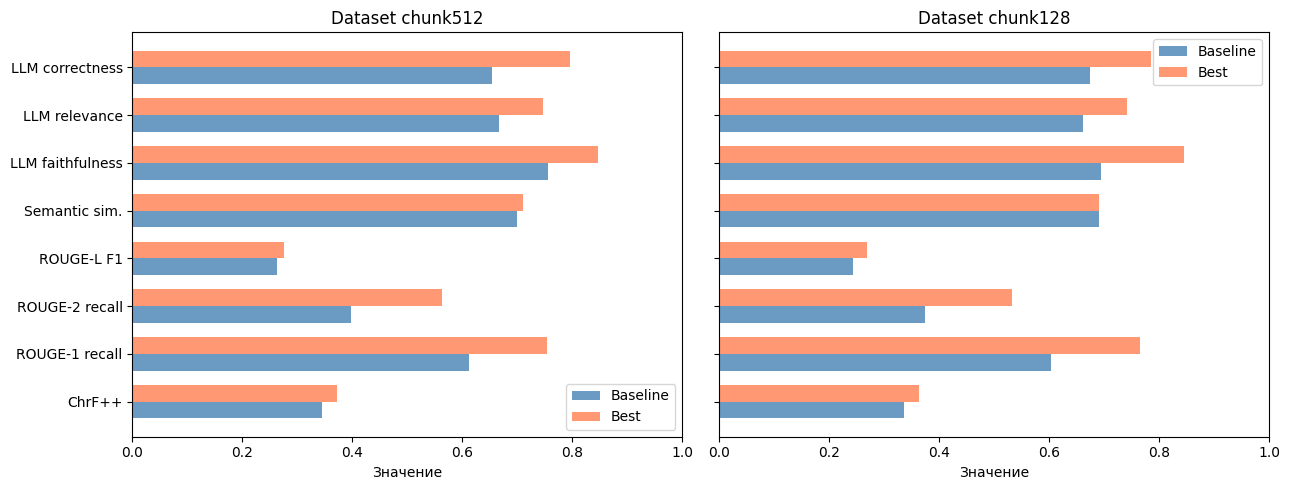

In [54]:
metric_titles = {
    "chrfpp": "ChrF++",
    "rouge1_recall": "ROUGE-1 recall",
    "rouge2_recall": "ROUGE-2 recall",
    "rougeL_f1": "ROUGE-L F1",
    "semantic_similarity": "Semantic sim.",
    "llm_faithfulness": "LLM faithfulness",
    "llm_answer_relevance": "LLM relevance",
    "llm_correctness": "LLM correctness",
}
plot_metrics = [m for m in GEN_METRICS if m in (comparison_512_df.columns) and comparison_512_df[m].notna().any()]

if plot_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(13, max(5, len(plot_metrics) * 0.35)), sharey=True)
    for ax, df, title in zip(axes, (comparison_512_df, comparison_128_df), ("Dataset chunk512", "Dataset chunk128")):
        x = np.arange(len(plot_metrics))
        width = 0.35
        if "baseline" in df.index and "best" in df.index:
            b_vals = [df.loc["baseline", m] if m in df.columns else np.nan for m in plot_metrics]
            f_vals = [df.loc["best", m] if m in df.columns else np.nan for m in plot_metrics]
            ax.barh(x - width/2, b_vals, width, label="Baseline", color="steelblue", alpha=0.8)
            ax.barh(x + width/2, f_vals, width, label="Best", color="coral", alpha=0.8)
        ax.set_yticks(x)
        ax.set_yticklabels([metric_titles.get(m, m) for m in plot_metrics])
        ax.set_xlabel("Значение")
        ax.set_title(title)
        ax.legend()
        ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

## Итоговые выводы

- **Метрики ретривера (baseline на chunk512 vs best на chunk128)**:
  - **Recall@k**: 0.693 → **0.870** (+0.177)
  - **MAP@k**: 0.533 → **0.658** (+0.125)
  - **nDCG@k**: 0.586 → **0.733** (+0.147)
  - **Hit rate**: 0.750 → **0.955** (+0.205)
  - **Precision@k**: 0.182 → **0.119** (−0.063)
  - **Интерпретация**: по ретриверу **best** заметно лучше по метрикам «попадания/ранжирования» (recall/MAP/nDCG/hit rate).

- **Качество генерации улучшилось стабильно на обоих датасетах**: конфиг **best** выигрывает у **baseline** практически по всем генеративным метрикам и на `chunk512`, и на `chunk128`.

- **Dataset chunk512**:
  - **ChrF++**: 0.344 → **0.371** (+0.027)
  - **ROUGE-1 recall**: 0.613 → **0.753** (+0.140)
  - **ROUGE-2 recall**: 0.398 → **0.564** (+0.166)
  - **ROUGE-L F1**: 0.263 → **0.275** (+0.012)
  - **Semantic similarity**: 0.700 → **0.710** (+0.010)
  - **LLM faithfulness**: 0.756 → **0.848** (+0.091)
  - **LLM answer relevance**: 0.666 → **0.746** (+0.080)
  - **LLM correctness**: 0.655 → **0.796** (+0.142)

- **Dataset chunk128**:
  - **ChrF++**: 0.336 → **0.363** (+0.027)
  - **ROUGE-1 recall**: 0.603 → **0.766** (+0.162)
  - **ROUGE-2 recall**: 0.374 → **0.533** (+0.160)
  - **ROUGE-L F1**: 0.244 → **0.269** (+0.025)
  - **Semantic similarity**: 0.691 → **0.691** (≈0; без изменений)
  - **LLM faithfulness**: 0.694 → **0.845** (+0.151)
  - **LLM answer relevance**: 0.662 → **0.742** (+0.080)
  - **LLM correctness**: 0.674 → **0.785** (+0.111)

- **Практический вывод**: улучшения **best** не «переобучены» под один конкретный датасет/чанкинг - приросты воспроизводятся на обоих (`chunk512` и `chunk128`). Поэтому **best** можно уверенно фиксировать как финальную конфигурацию для полного прогона и сравнения с сохранённым бейзлайном.
